# AirBnB NYC Analytics Project

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-nyc-product-analytics-project) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 04. Host Revenue Model

> "Is the target market for HostLens real and large enough to justify building it?"

If HostLens targets underperforming hosts, that segment needs to be sizable enough to justify the product investment. This notebook builds the revenue model to answer that question: how many hosts fall into the target group, and what is the aggregate revenue opportunity if HostLens helped them lift occupancy.

**Proxy:**
- Occupancy proxy = `(365 − availability 365) / 365`
- Implied annual revenue = `occupancy × price × 365`

**Limitations:** The dataset doesn't include booking data. Occupancy and revenue are estimates based on the availability field, which reflects how many days the host has set aside as bookable. Findings should be read as directional patterns rather than exact revenue claims.

**My Approach:**
1. Build the occupancy and revenue proxies
2. Explore how revenue varies across borough and price tier
3. Test whether availability tier predicts rating (ANOVA moved from Notebook 03)
4. Isolate the high-rating, low-occupancy segment - the target audience for HostLens
5. Quantify the aggregate revenue opportunity to inform the build decision

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')

# Apply Airbnb branding
airbnb_coral = '#FF5A5F'
airbnb_teal = '#00A699'
airbnb_orange = '#FC642D'
airbnb_dark = '#484848'
airbnb_gray = '#767676'

airbnb_palette = [airbnb_coral, airbnb_teal, airbnb_orange, airbnb_dark, airbnb_gray]
sns.set_palette(airbnb_palette)
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

print(f"Dataset: {df.shape[0]:,} listings")

Dataset: 63,718 listings


# 1. Build the occupancy and revenue proxies

Since the dataset has no booking data, my analysis uses 2 proxies:

* **Occupancy proxy:** the rate of the year not marked as available. A listing with 100 days of availability has an occupancy proxy of 0.73.

* **Estimated annual revenue:** occupancy × price × 365. A listing at $150/night with 60% occupancy has an estimated revenue of ~$32,850.

These are estimates from the dataset, not actual bookings, so both proxies are read as relative comparisons across listings rather than absolute dollar figures.

In [2]:
# Build occupancy proxy
df['occupancy_proxy'] = (365 - df['availability 365']) / 365

In [3]:

# Build estimated annual revenue
df['estimated_revenue'] = df['occupancy_proxy'] * df['price'] * 365

In [4]:
# Sanity check
print("Occupancy proxy:")
print(df['occupancy_proxy'].describe())
print("\nEstimated annual revenue:")
print(df['estimated_revenue'].describe())

Occupancy proxy:
count    63718.000000
mean         0.525846
std          0.329678
min          0.000000
25%          0.213699
50%          0.556164
75%          0.827397
max          0.997260
Name: occupancy_proxy, dtype: float64

Estimated annual revenue:
count     63718.000000
mean     120184.175115
std      106175.855018
min           0.000000
25%       29498.500000
50%       90597.000000
75%      190340.000000
max      436436.000000
Name: estimated_revenue, dtype: float64


# 2. Distribution of estimated revenue

Before comparing groups, this histogram shows how estimated revenue is distributed across all NYC listings.

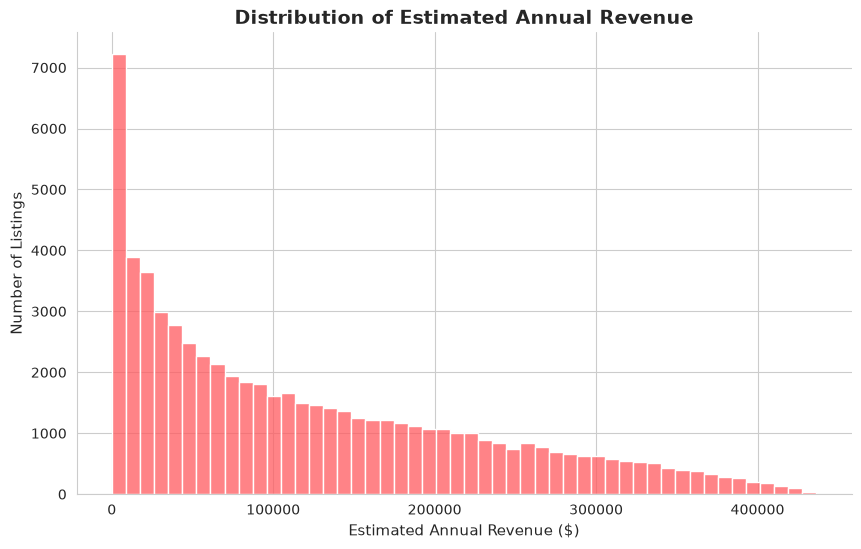

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='estimated_revenue', bins=50)
plt.title('Distribution of Estimated Annual Revenue')
plt.xlabel('Estimated Annual Revenue ($)')
plt.ylabel('Number of Listings')
plt.show()

### Key Takeaway

* Estimated annual revenue ranges from $0 to $436,436, with a median of $90,597 and a mean of $120,184

* This distribution is heavily right-skewed: over 7,000 listings sit near zero revenue, and the count drops steadily as revenue increases.

→ The right skew is expected. Most listings are budget-to-mid tier with moderate occupancy, and a small number of premium listings with high occupancy earn dramatically more

→ We need to look into the large group near zero when segmneting the high revenue-low occupancy group later, which are likely listings that are either very low availability or very low price, resulting in being barely active

# 3. Revenue by borough

This chart shows how estimated  annual revenue varies across the 5 boroughs. Combined with the borough supply data from Notebook 02, this chart shows where the revenue-per-listing is concentrated.

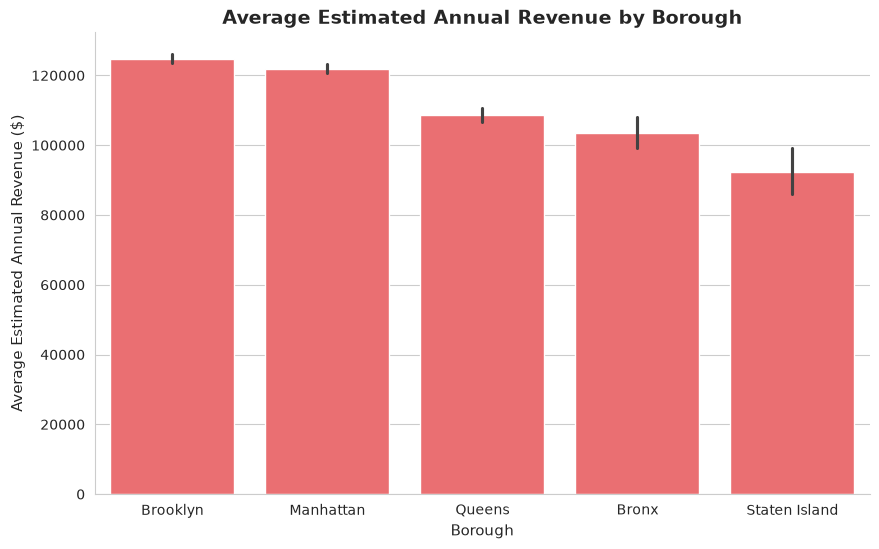

                         mean   median  count
neighbourhood group                          
Bronx                103586.0  67944.0   2049
Brooklyn             124798.0  95424.0  25775
Manhattan            121874.0  93620.0  25747
Queens               108768.0  73856.0   9388
Staten Island         92175.0  57805.0    759


In [8]:
# Average estimated revenue by borough
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='neighbourhood group', y='estimated_revenue',
            order=df.groupby('neighbourhood group')['estimated_revenue'].mean().sort_values(ascending=False).index)
plt.title('Average Estimated Annual Revenue by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Estimated Annual Revenue ($)')
plt.show()

# Print averages
print(df.groupby('neighbourhood group')['estimated_revenue'].agg(['mean', 'median', 'count']).round(0))

### Key Takeaway

* Brooklyn ($124,437) and Manhattan ($121,505) lead average revenue, followed by Queens ($108,254), the Bronx ($103,109), and Staten Island ($92,043)

* The gap between the top and bottom borough is about $32,000 per listing.

→ Notebook 02 showed that Queens leads on reviews per month, but here Brooklyn and Manhattan lead on revenue. The 2 metrics reflect different things: reviews per month captures booking frequency, while revenue also factors in nightly price

→ Brooklyn and Manhattan command higher prices, which lifts revenue even when per-listing demand is lower

* Similar to Notebook 02, Staten Island's wider error bar reflects its small sample (759 listings), so its revenue figure is less reliable.

# 4. Availability ANOVA

* Availability is a host-controlled setting. Here, we will check if the level of availability affects rating

* Listings are binned into 4 availability tiers, and a one-way ANOVA tests whether ratings differ significantly across them.

In [13]:
# Bin availability into tiers
df['availability_group'] = pd.cut(df['availability 365'],
                                  bins=[-1, 90, 180, 270, 365],
                                  labels=['Very Low (0-90)', 'Low (91-180)', 'Medium (181-270)', 'High (271-365)'])


In [14]:
# Split groups
very_low = df[df['availability_group'] == 'Very Low (0-90)']['review rate number']
low = df[df['availability_group'] == 'Low (91-180)']['review rate number']
medium = df[df['availability_group'] == 'Medium (181-270)']['review rate number']
high = df[df['availability_group'] == 'High (271-365)']['review rate number']

In [15]:

# ANOVA Test
f_stat, p_value = stats.f_oneway(very_low, low, medium, high)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")


F-statistic: 8.6482
P-value: 0.0000


In [16]:

# Sample sizes and means
print(f"\nGroup means and sample sizes:")
print(df.groupby('availability_group')['review rate number'].agg(['mean', 'count']).round(4))


Group means and sample sizes:
                      mean  count
availability_group               
Very Low (0-90)     3.3180  22593
Low (91-180)        3.2789  12839
Medium (181-270)    3.2424  10186
High (271-365)      3.2917  18100


### Key Takeaway

* Very Low availability listings (0-90 days per year) rate highest at 3.32 stars

* Medium availability (181-270 days) rates lowest at 3.24. The pattern is not linear, as High availability (271-365 days) recovers to 3.29, close to the Very Low group.

→ This means "less available" doesn't cleanly translate to "better rated" or "worse rated." 

→ Therefore, Tukey HSD will tell us which of these differences are real and which are noise, sepcfically when the ANOVA is highly significant (p < 0.0001)

In [17]:
# Tukey's HSD 
tukey = pairwise_tukeyhsd(df['review rate number'], df['availability_group'], alpha=0.05)
print(tukey)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
  High (271-365)     Low (91-180)  -0.0127 0.8234 -0.0506  0.0251  False
  High (271-365) Medium (181-270)  -0.0493   0.01 -0.0899 -0.0086   True
  High (271-365)  Very Low (0-90)   0.0263 0.1649 -0.0064  0.0591  False
    Low (91-180) Medium (181-270)  -0.0365 0.1364 -0.0801   0.007  False
    Low (91-180)  Very Low (0-90)   0.0391 0.0291  0.0028  0.0753   True
Medium (181-270)  Very Low (0-90)   0.0756    0.0  0.0364  0.1148   True
------------------------------------------------------------------------


### Key Takeaway

* ANOVA p < 0.0001. The overall difference across availability tiers is statistically significant

**Tukey's HSD identifies 3 significant pairs:**
1. Medium vs Very Low (p = 0.0000, meandiff = 0.076): Very Low rates higher
2. Low vs Very Low (p = 0.0291, meandiff = 0.039): Very Low rates higher
3. High vs Medium (p = 0.0100, meandiff = -0.049): High rates higher than Medium


→ The finding suggests 2 groups of hosts perform well on ratings: those who are highly selective (Very Low) and those running near-year-round operations (High)

→ The Medium group rates lowest, which is consistent with host profiles that are available enough to attract bookings, but without the operational focus of a full-time host

→ This finding is a good host-side recommendation but shouldn't be overstated, since the gaps are small (0.05-0.08 stars) 

# 5. The unused revenue segment

This is the core Q3 analysis: which hosts are underperforming despite strong ratings?

**Filter requirement:**
* Rating ≥ 4.5 stars (high quality)
* Occupancy proxy < 0.5 (less than half the year booked)

→ Hosts in this segment have the quality signal that guests trust but low booking activity

→ They are the target audience for Airbnb HostLens prototype.

In [20]:
# Filter to the unused revenue segment
unused_revenue = df[(df['review rate number'] >= 4.5) & (df['occupancy_proxy'] < 0.5)]

print(f"Total listings: {len(df):,}")
print(f"Unused revenue segment: {len(unused_revenue):,}")
print(f"Share of total: {len(unused_revenue) / len(df) * 100:.1f}%")

print(f"\nSegment averages:")
print(f"  *Average rating: {unused_revenue['review rate number'].mean():.2f}")
print(f"  *Average occupancy: {unused_revenue['occupancy_proxy'].mean():.2f}")
print(f"  *Average price: ${unused_revenue['price'].mean():.0f}")
print(f"  *Average estimated revenue: ${unused_revenue['estimated_revenue'].mean():,.0f}")

Total listings: 63,718
Unused revenue segment: 6,412
Share of total: 10.1%

Segment averages:
  *Average rating: 5.00
  *Average occupancy: 0.19
  *Average price: $620
  *Average estimated revenue: $43,672


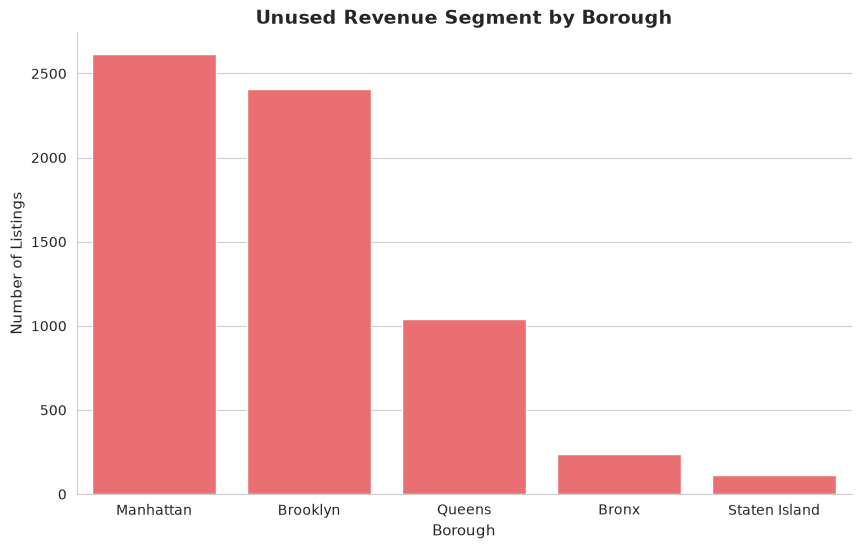

neighbourhood group
Manhattan        2615
Brooklyn         2405
Queens           1041
Bronx             239
Staten Island     112
Name: count, dtype: int64


In [21]:
# Borough breakdown of the segment
plt.figure(figsize=(10, 6))
sns.countplot(data=unused_revenue, x='neighbourhood group',
              order=unused_revenue['neighbourhood group'].value_counts().index)
plt.title('Unused Revenue Segment by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.show()

print(unused_revenue['neighbourhood group'].value_counts())

In [23]:
# Estimate the revenue gap: what if these listings got to 70% occupancy?
target_occupancy = 0.70
unused_revenue = unused_revenue.copy()
unused_revenue['potential_revenue'] = target_occupancy * unused_revenue['price'] * 365
unused_revenue['revenue_gap'] = unused_revenue['potential_revenue'] - unused_revenue['estimated_revenue']

print(f"Total current estimated revenue in segment: ${unused_revenue['estimated_revenue'].sum():,.0f}")
print(f"Total potential revenue at 70% occupancy: ${unused_revenue['potential_revenue'].sum():,.0f}")
print(f"Aggregate revenue gap: ${unused_revenue['revenue_gap'].sum():,.0f}")
print(f"Average gap per listing: ${unused_revenue['revenue_gap'].mean():,.0f}")

Total current estimated revenue in segment: $280,023,669
Total potential revenue at 70% occupancy: $1,015,142,636
Aggregate revenue gap: $735,118,966
Average gap per listing: $114,647


### Key Takeaway

* Average price in segment: $620/night (vs. dataset average likely around $200–300)

* Average occupancy: 19% (barely used)

* Average rating: 5.00 
 
* The unused revenue segment includes 6,412 listings, or 10.1% of the dataset. These hosts average a 5-star rating but only 19% occupancy, at $620 per night. Their current estimated revenue is $280M, and lifting them to 70% occupancy would bring it to $1.02B, which is an aggregate gap of $735M, or an average of $114,647 per listing.

* The segment is heavily concentrated in Manhattan (2,615) and Brooklyn (2,405), with Queens (1,041), the Bronx (239), and Staten Island (112) making up the rest.

**Interpretation**

* These aren't hosts who need help running a listing, but they already earn 5 stars, which means the guest experience is strong. What's missing is booking activity. That points to positioning, seasonal demand, and visibility, which is the exact areas Airbnb HostLens can target. A prototype that helps 5% of this segment lift occupancy by even 20% points would represent a meaningful revenue impact.

→ **Note:** The 5-star average reflects a limitation in the dataset. Real Airbnb ratings cluster between 4.5 and 5.0, so the same filter on real live data would surface a larger and more varied segment.

Since Bronx was marked in Notebook 02 to have high average number of reviews but with low supply, we will do a quick check of Bronx

In [ ]:
#Quick check through Bronx

bronx = df[df['neighbourhood group'] == 'Bronx']
print(f"Bronx listings: {len(bronx):,}")
print(f"Bronx average rating: {bronx['review rate number'].mean():.2f}")
print(f"Bronx average occupancy: {bronx['occupancy_proxy'].mean():.2f}")
print(f"Bronx average estimated revenue: ${bronx['estimated_revenue'].mean():,.0f}")

Bronx listings: 2,049
Bronx average rating: 3.36
Bronx average occupancy: 0.45
Bronx average estimated revenue: $103,586


### Key Takeaway

* The Bronx has 2,049 listings, average rating of 3.36 (the highest of any borough), average occupancy of 45%, and average revenue of $103,586. Compared to Brooklyn and Manhattan, which each hold roughly 25,000 listings, the Bronx supply is 1/10 the size despite showing the highest per-listing rating in the city.

→ **Note:** The Bronx should also be presented as a second opportunity. While the unused revenue segment is about helping existing hosts book more nights, The Bronx gap is about attracting new hosts into an undersupplied borough.

## Summary

| Analysis | Finding |
|---|---|
| Revenue distribution | Heavily right-skewed (median $90,597, mean $120,184, max $436,436) and over 7,000 listings near $0 |
| Revenue by borough | Brooklyn leads with $124,437. Manhattan and Brooklyn command higher revenue despite lower per-listing demand than Queens, because they command higher prices |
| Availability ANOVA | p < 0.0001, which shows it being significant. Very Low availability (0–90 days) rates highest at 3.32 stars, Medium (181–270) lowest at 3.24. The pattern is not linear, however, as highly selective hosts and near-year-round hosts both outperform the middle group. |
| Unused revenue segment | 6,412 listings (10.1% of dataset), average 5-star rating, 19% occupancy, $620/night. Aggregate revenue gap of $735M if lifted to 70% occupancy, which is an average of $114,647 per listing. |

→ The unused revenue segment is the target audience for the Airbnb HostLens. These are premium listings with proven quality that book <70 nights a year

→ Airbnb needs to address positioning, visibility, and seasonal demand for these listings

## Handoff

These findings lead to 2 sources:

**Notebook 06** The unused revenue segment and the availability ANOVA finding will be combined with Notebooks 03 and 05 findings into the final recommendation for hoss. I will also propose A/B Testing to validate these recommendations 

**Vacancy Coach prototype:** The unused revenue segment defines the target user, and HostLens will take a listing from this segment as input and generate specific recommendations to reduce vacancy.